In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Modelos de Regresión Lineal

El **análisis de regresión** estudia la relación entre una variable de respuesta $y$ y una o más variables explicativas $x_1, x_2, \ldots, x_p$. Es una de las herramientas estadísticas más usadas en ingeniería y ciencias, con aplicaciones que van desde el modelamiento de procesos industriales hasta el análisis de datos económicos.

## ¿Cuándo usar regresión?

- Para **cuantificar** la relación entre variables continuas.
- Para **predecir** el valor de una variable a partir de otras.
- Para **controlar** el efecto de variables de confusión.

## Contenidos de este capítulo

1. **Correlación**: medir la fuerza y dirección de la asociación lineal.
2. **Regresión lineal simple**: un predictor, una respuesta.
3. **Bondad de ajuste**: cuánto explica el modelo ($R^2$, RSE).
4. **Inferencia**: ¿es la relación estadísticamente significativa?
5. **Diagnósticos**: verificar los supuestos del modelo.
6. **Remediación**: transformaciones cuando los supuestos se violan.
7. **Regresión lineal múltiple**: extender a varios predictores.

---
## 1. Correlación

Antes de ajustar un modelo de regresión conviene explorar la **asociación lineal** entre las variables. La **matriz de correlación** permite identificar rápidamente qué pares de variables merecen ser modelados.

Usaremos el dataset de ventas de videojuegos como primer caso exploratorio.

In [2]:
def read_course_dataset(name):
    link = 'https://github.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/SetDeDatos/'
    link += name + '?raw=true'
    df = pd.read_csv(link)
    if 'Unnamed: 0' in df.columns:
        df = df.drop('Unnamed: 0', axis=1)
    return df

vg = read_course_dataset('Video_Game_Sales_as_of_Jan_2017.csv')

# Seleccionamos variables numericas y eliminamos valores faltantes
cols_num = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales',
            'Critic_Score', 'User_Score']
vg_num = vg[cols_num].dropna()
print(f'Observaciones disponibles: {len(vg_num)}')
vg_num.describe().round(2)

Observaciones disponibles: 7191


,NA_Sales,EU_Sales,JP_Sales,Global_Sales,Critic_Score,User_Score
count,7191.00,7191.00,7191.00,7191.00,7191.00,7191.00
mean,0.38,0.23,0.06,0.76,70.22,7.17
std,0.95,0.68,0.28,1.93,13.88,1.44
min,0.00,0.00,0.00,0.01,13.00,0.50
25%,0.05,0.02,0.00,0.11,62.00,6.50
50%,0.14,0.06,0.00,0.28,72.00,7.50
75%,0.38,0.20,0.01,0.74,80.00,8.20
max,41.36,28.96,6.50,82.54,98.00,9.60


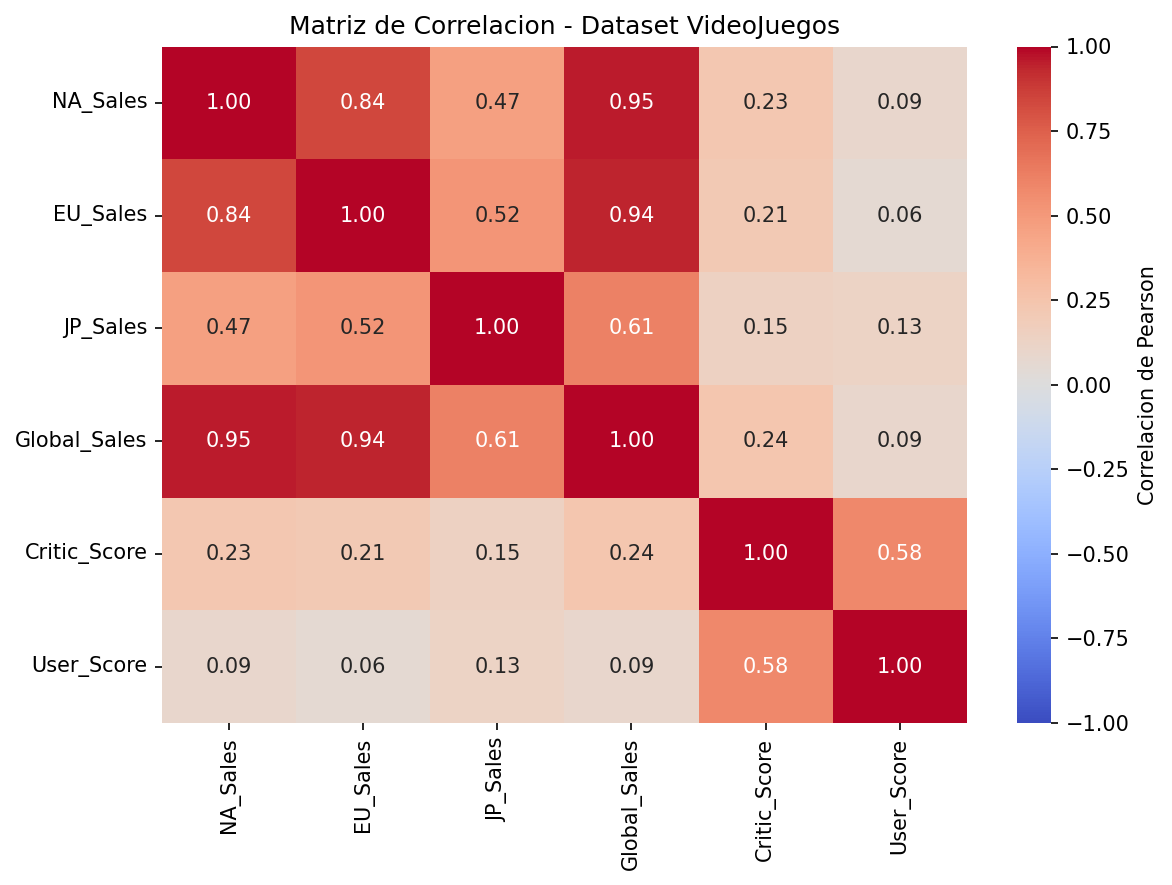

In [3]:
# Mapa de calor de la matriz de correlacion de Pearson
corr = vg_num.corr()

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'})
ax.set_title('Matriz de Correlacion - Dataset VideoJuegos')
plt.tight_layout()
plt.show()

### 1.1 Correlación de Pearson

La **correlación de Pearson** mide la fuerza y dirección de la relación *lineal* entre dos variables continuas:

$$R_{XY} = \frac{S_{XY}}{\sqrt{S_{XX} \cdot S_{YY}}}$$

donde
$$S_{XY} = \sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y}), \quad S_{XX} = \sum_{i=1}^{n}(x_i - \bar{x})^2, \quad S_{YY} = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

**Propiedades:**
- $R \in [-1, 1]$
- $|R| = 1$: relación lineal perfecta; $R = 0$: sin asociación lineal.
- Es sensible a valores atípicos.

**Test de hipótesis** para la correlación:
$$H_0: \rho = 0 \qquad H_a: \rho \neq 0$$
$$T_0 = \frac{R\sqrt{n-2}}{\sqrt{1-R^2}} \sim t_{n-2} \quad \text{bajo } H_0$$

In [4]:
x_cr = vg_num['Critic_Score']
y_gs = vg_num['Global_Sales']
n = len(x_cr)

# Calculo manual
x_bar, y_bar = x_cr.mean(), y_gs.mean()
S_XY = np.sum((x_cr - x_bar) * (y_gs - y_bar))
S_XX = np.sum((x_cr - x_bar) ** 2)
S_YY = np.sum((y_gs - y_bar) ** 2)
r_manual = S_XY / np.sqrt(S_XX * S_YY)

# Calculo con scipy (incluye test de hipotesis)
r_scipy, p_valor = stats.pearsonr(x_cr, y_gs)

# Estadistico T_0 manual
T0 = r_manual * np.sqrt(n - 2) / np.sqrt(1 - r_manual**2)

print('Critic Score -> Global Sales')
print(f'  R (manual) = {r_manual:.4f}')
print(f'  R (scipy)  = {r_scipy:.4f}')
print(f'  T_0        = {T0:.4f}')
print(f'  p-value    = {p_valor:.2e}')

# Comparacion con User Score
r_us, p_us = stats.pearsonr(vg_num['User_Score'], y_gs)
print()
print('User Score -> Global Sales')
print(f'  R = {r_us:.4f},  p-value = {p_us:.2e}')

Critic Score -> Global Sales
  R (manual) = 0.2368
  R (scipy)  = 0.2368
  T_0        = 20.6660
  p-value    = 3.22e-92

User Score -> Global Sales
  R = 0.0882,  p-value = 6.70e-14


### 1.2 Correlación de Spearman

La **correlación de Spearman** ($\rho_s$) es la versión no paramétrica de Pearson: trabaja con los **rangos** de los datos en lugar de los valores originales. Es más robusta frente a valores atípicos y detecta relaciones **monótonas** (no necesariamente lineales).

| | Pearson | Spearman |
|---|---|---|
| Mide | Relación lineal | Relación monotónica |
| Requiere | Normalidad aproximada | Sin supuesto distribucional |
| Sensible a outliers | Sí | No |
| Símbolo | $R$ | $\rho_s$ |

In [5]:
# Correlaciones de Spearman para las mismas variables
rho_cr, p_rho_cr = stats.spearmanr(x_cr, y_gs)
rho_us, p_rho_us = stats.spearmanr(vg_num['User_Score'], y_gs)

resultados = pd.DataFrame({
    'Variable':      ['Critic Score', 'User Score'],
    'Pearson R':     [r_scipy,  r_us],
    'Spearman rho':  [rho_cr,   rho_us],
    'p-value (Pear)':[p_valor,  p_us],
    'p-value (Spear)':[p_rho_cr, p_rho_us]
})
resultados.round(4)

,Variable,Pearson R,Spearman rho,p-value (Pear),p-value (Spear)
0,Critic Score,0.2368,0.3758,0.0,0.0
1,User Score,0.0882,0.1578,0.0,0.0


---
## 2. Regresión Lineal Simple

La **regresión lineal simple** modela la relación entre una variable explicativa $x$ y una variable de respuesta $y$ mediante una recta:

$$Y = \beta_0 + \beta_1 x + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

Donde:
- $\beta_0$: intercepto (valor esperado de $Y$ cuando $x = 0$).
- $\beta_1$: pendiente (cambio esperado en $Y$ por unidad de aumento en $x$).
- $\varepsilon$: error aleatorio, captura variabilidad no explicada por $x$.

**Supuestos del modelo:**
1. Linealidad: $E[Y|x] = \beta_0 + \beta_1 x$.
2. Independencia: las observaciones son independientes.
3. Homocedasticidad: $\text{Var}(\varepsilon) = \sigma^2$ constante.
4. Normalidad: $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.

### Caso de estudio: Pureza de Oxígeno

Un ingeniero estudia cómo el nivel de hidrocarburos ($x$, en %) en el gas de entrada afecta la pureza del oxígeno producido ($y$, en %). Este es el ejemplo clásico del Capítulo 11 de Montgomery & Runger (2019).

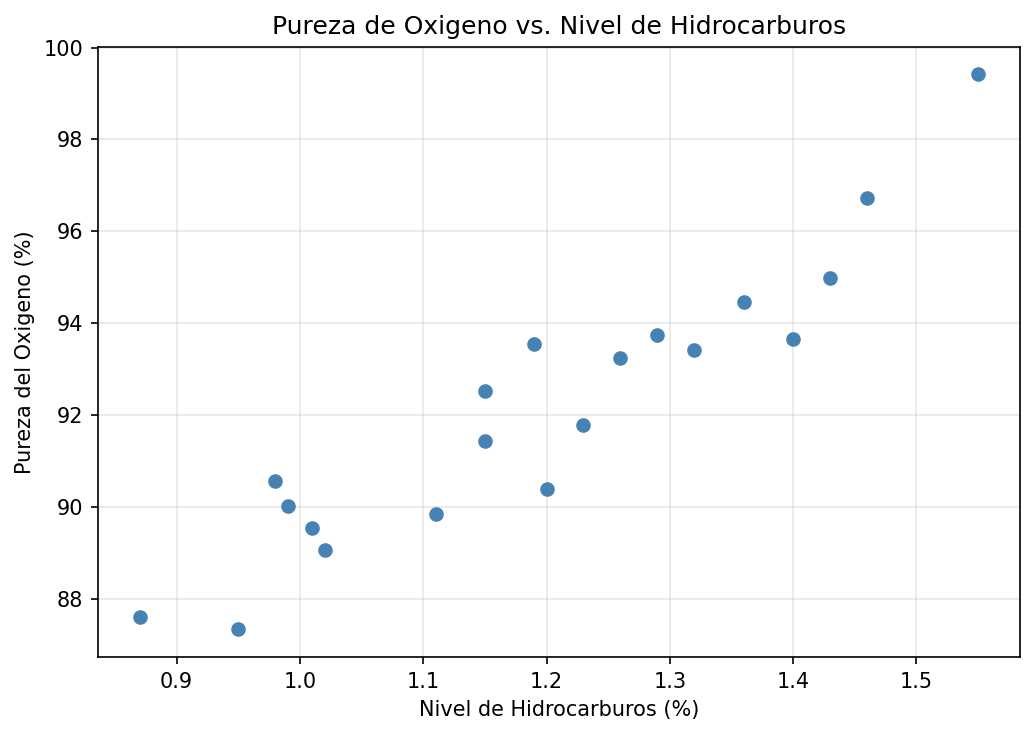

           hc  pureza
count  20.000  20.000
mean    1.196  92.161
std     0.189   3.021
min     0.870  87.330
25%     1.018  89.970
50%     1.195  92.145
75%     1.330  93.672
max     1.550  99.420


In [6]:
data_pureza = {
    'hc':     [0.99, 1.02, 1.15, 1.29, 1.46, 1.36, 0.87, 1.23, 1.55, 1.40,
               1.19, 1.15, 0.98, 1.01, 1.11, 1.20, 1.26, 1.32, 1.43, 0.95],
    'pureza': [90.01, 89.05, 91.43, 93.74, 96.73, 94.45, 87.59, 91.77,
               99.42, 93.65, 93.54, 92.52, 90.56, 89.54, 89.85, 90.39,
               93.25, 93.41, 94.98, 87.33]
}
df = pd.DataFrame(data_pureza)

# Analisis exploratorio
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ax.scatter(df['hc'], df['pureza'], color='steelblue', zorder=3)
ax.set_xlabel('Nivel de Hidrocarburos (%)')
ax.set_ylabel('Pureza del Oxigeno (%)')
ax.set_title('Pureza de Oxigeno vs. Nivel de Hidrocarburos')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(df.describe().round(3))

### 2.1 Estimación por Mínimos Cuadrados Ordinarios (OLS)

El método de **mínimos cuadrados ordinarios** minimiza la suma de los cuadrados de los residuos:

$$\min_{\beta_0, \beta_1} \; L = \sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_i)^2$$

Derivando e igualando a cero, se obtienen las **ecuaciones normales**:

$$\hat{\beta}_1 = \frac{S_{XY}}{S_{XX}}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

**Conexión con la correlación de Pearson:**

$$\hat{\beta}_1 = R_{XY} \cdot \frac{s_y}{s_x}$$

donde $s_x$ y $s_y$ son las desviaciones estándar muestrales. Esto implica que $\hat{\beta}_1$ y $R_{XY}$ siempre tienen el mismo signo.

beta_0 (intercepto) = 74.2833
beta_1 (pendiente)  = 14.9475
beta_1 via Pearson  = 14.9475  (verificacion)


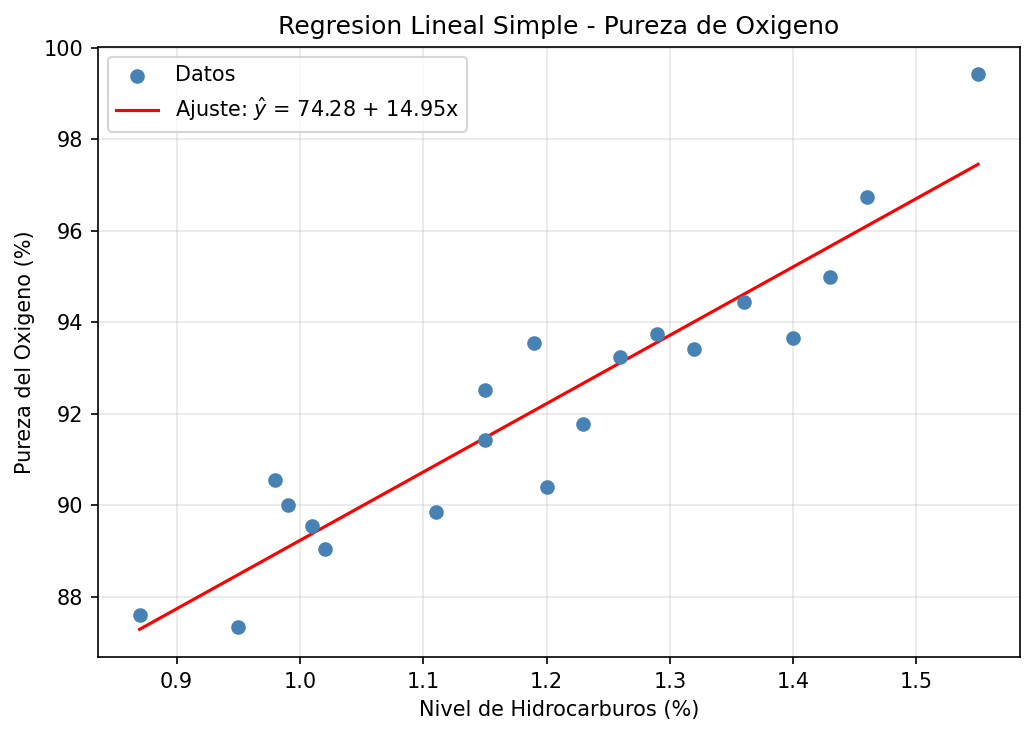

In [7]:
x = df['hc']
y = df['pureza']
n_o = len(x)

x_bar_o = x.mean()
y_bar_o = y.mean()

# Estimadores OLS manuales
S_XY_o = np.sum((x - x_bar_o) * (y - y_bar_o))
S_XX_o = np.sum((x - x_bar_o) ** 2)

beta1_hat = S_XY_o / S_XX_o
beta0_hat = y_bar_o - beta1_hat * x_bar_o

# Verificacion via correlacion de Pearson
R_o = stats.pearsonr(x, y)[0]
beta1_via_r = R_o * (y.std(ddof=1) / x.std(ddof=1))

print(f'beta_0 (intercepto) = {beta0_hat:.4f}')
print(f'beta_1 (pendiente)  = {beta1_hat:.4f}')
print(f'beta_1 via Pearson  = {beta1_via_r:.4f}  (verificacion)')

# Visualizacion con la recta ajustada
x_range = np.linspace(x.min(), x.max(), 100)
y_hat_range = beta0_hat + beta1_hat * x_range

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ax.scatter(x, y, color='steelblue', label='Datos', zorder=3)
ax.plot(x_range, y_hat_range, color='red',
        label=f'Ajuste: $\\hat{{y}}$ = {beta0_hat:.2f} + {beta1_hat:.2f}x')
ax.set_xlabel('Nivel de Hidrocarburos (%)')
ax.set_ylabel('Pureza del Oxigeno (%)')
ax.set_title('Regresion Lineal Simple - Pureza de Oxigeno')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Ajuste con `statsmodels`

En la práctica se usa la función `sm.OLS` de `statsmodels`, que entrega un resumen completo del modelo. El método `summary()` incluye:

- **Coeficientes** $\hat{\beta}_0$ y $\hat{\beta}_1$ con errores estándar.
- **$R^2$** y $R^2$ ajustado.
- **Estadístico F** y su p-value (significancia global del modelo).
- **p-values** individuales para cada coeficiente.
- **Intervalos de confianza** al 95%.

> **Nota importante:** `sm.add_constant(x)` agrega la columna de unos necesaria para estimar el intercepto $\beta_0$. Sin esto, el modelo fuerza la recta a pasar por el origen.

In [8]:
# Ajuste OLS con statsmodels
X = sm.add_constant(x)  # agrega columna de intercepto
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 pureza   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     128.9
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           1.23e-09
Time:                        00:54:14   Log-Likelihood:                -28.985
No. Observations:                  20   AIC:                             61.97
Df Residuals:                      18   BIC:                             63.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.2833      1.593     46.617      0.0

---
## 3. Bondad de Ajuste

### 3.1 Coeficiente de Determinación $R^2$

El $R^2$ mide la **fracción de variabilidad total** de $y$ explicada por el modelo:

$$R^2 = \frac{SS_R}{SS_T} = 1 - \frac{SS_E}{SS_T}$$

donde
$$SS_T = \sum_{i=1}^n (y_i - \bar{y})^2, \quad SS_E = \sum_{i=1}^n (y_i - \hat{y}_i)^2, \quad SS_R = SS_T - SS_E$$

- $R^2 \in [0, 1]$: más cercano a 1 indica mejor ajuste.
- Para regresión lineal simple: $R^2 = R_{XY}^2$ (el cuadrado de la correlación de Pearson).

### 3.2 Error Estándar Residual (RSE)

El RSE estima la desviación estándar del error $\sigma$:

$$\hat{\sigma} = RSE = \sqrt{\frac{SS_E}{n - 2}} = \sqrt{MS_E}$$

Tiene las **mismas unidades que $y$** y representa el error promedio del modelo en escala original.

In [9]:
y_hat = modelo.fittedvalues
residuos = modelo.resid

SS_T = np.sum((y - y.mean()) ** 2)
SS_E = np.sum(residuos ** 2)
SS_R = SS_T - SS_E

R2_manual = 1 - SS_E / SS_T
RSE = np.sqrt(SS_E / (n_o - 2))

print('Descomposicion de la varianza:')
print(f'  SS_T  = {SS_T:.4f}  (variabilidad total)')
print(f'  SS_R  = {SS_R:.4f}  (explicada por el modelo)')
print(f'  SS_E  = {SS_E:.4f}  (no explicada / residuos)')
print()
print(f'R^2 (manual)   = {R2_manual:.4f}')
print(f'R^2 (modelo)   = {modelo.rsquared:.4f}  (verificacion)')
print(f'R^2 ajustado   = {modelo.rsquared_adj:.4f}')
print(f'RSE (sigma^)   = {RSE:.4f}')
print()
print(f'Interpretacion: el modelo explica el {R2_manual*100:.1f}% de la variabilidad de la pureza.')

Descomposicion de la varianza:
  SS_T  = 173.3769  (variabilidad total)
  SS_R  = 152.1271  (explicada por el modelo)
  SS_E  = 21.2498  (no explicada / residuos)

R^2 (manual)   = 0.8774
R^2 (modelo)   = 0.8774  (verificacion)
R^2 ajustado   = 0.8706
RSE (sigma^)   = 1.0865

Interpretacion: el modelo explica el 87.7% de la variabilidad de la pureza.


---
## 4. Inferencia sobre la Regresión

### 4.1 Test para la pendiente

La pregunta más importante en regresión es: **¿existe realmente una relación lineal entre $x$ e $y$?** Esto equivale a:

$$H_0: \beta_1 = 0 \qquad H_a: \beta_1 \neq 0$$

El estadístico de prueba es:
$$T_0 = \frac{\hat{\beta}_1}{se(\hat{\beta}_1)} \sim t_{n-2} \quad \text{bajo } H_0$$

donde $se(\hat{\beta}_1) = \sqrt{MS_E / S_{XX}}$.

### 4.2 Intervalos de confianza para los coeficientes

El IC al $100(1-\alpha)\%$ para $\beta_1$ es:
$$\hat{\beta}_1 \pm t_{\alpha/2,\, n-2} \cdot se(\hat{\beta}_1)$$

In [10]:
# Extraccion de resultados de inferencia del modelo
beta0_est, beta1_est = modelo.params
se_beta0, se_beta1   = modelo.bse
t_beta0, t_beta1     = modelo.tvalues
p_beta0, p_beta1     = modelo.pvalues

ci = modelo.conf_int()  # IC 95% por defecto

print('Inferencia sobre los coeficientes:')
print(f'  beta_0: {beta0_est:.4f}  +/-  {se_beta0:.4f}   t={t_beta0:.2f}  p={p_beta0:.4e}')
print(f'    IC 95%: [{ci.loc["const",0]:.4f}, {ci.loc["const",1]:.4f}]')
print()
print(f'  beta_1: {beta1_est:.4f}  +/-  {se_beta1:.4f}   t={t_beta1:.2f}  p={p_beta1:.4e}')
print(f'    IC 95%: [{ci.loc["hc",0]:.4f}, {ci.loc["hc",1]:.4f}]')
print()
if p_beta1 < 0.05:
    print('Conclusion: rechazamos H0 (beta_1 = 0). El nivel de hidrocarburos')
    print('tiene un efecto significativo sobre la pureza (p < 0.05).')

Inferencia sobre los coeficientes:
  beta_0: 74.2833  +/-  1.5935   t=46.62  p=3.1715e-20
    IC 95%: [70.9356, 77.6311]

  beta_1: 14.9475  +/-  1.3168   t=11.35  p=1.2273e-09
    IC 95%: [12.1811, 17.7139]

Conclusion: rechazamos H0 (beta_1 = 0). El nivel de hidrocarburos
tiene un efecto significativo sobre la pureza (p < 0.05).


### 4.3 ANOVA para Regresión

La significancia global del modelo también se puede evaluar con la **tabla ANOVA**:

| Fuente | SS | gl | MS | $F_0$ |
|--------|----|----|-------|-------|
| Regresión | $SS_R = \hat{\beta}_1 S_{XY}$ | 1 | $MS_R$ | $F_0 = MS_R / MS_E$ |
| Error | $SS_E$ | $n-2$ | $MS_E$ | |
| Total | $SS_T$ | $n-1$ | | |

Bajo $H_0: \beta_1 = 0$, el estadístico $F_0 \sim F_{1, n-2}$. Se rechaza $H_0$ cuando $F_0 > f_{\alpha, 1, n-2}$.

> Para regresión lineal simple: $F_0 = T_0^2$, por lo que el test ANOVA y el t-test para $\beta_1$ son equivalentes.

In [11]:
from statsmodels.formula.api import ols as smf_ols

# Tabla ANOVA para regresion
modelo_formula = smf_ols('pureza ~ hc', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_formula, typ=1)
print('Tabla ANOVA para la regresion lineal simple:')
print(tabla_anova)
print()

# Verificacion: F_0 = T_0^2
F0 = modelo.fvalue
T0_beta1 = t_beta1
print(f'F_0 del modelo    = {F0:.4f}')
print(f'T_0^2 (beta_1)    = {T0_beta1**2:.4f}  (deben ser iguales en SLR)')

Tabla ANOVA para la regresion lineal simple:
            df      sum_sq     mean_sq           F        PR(>F)
hc         1.0  152.127078  152.127078  128.861694  1.227314e-09
Residual  18.0   21.249817    1.180545         NaN           NaN

F_0 del modelo    = 128.8617
T_0^2 (beta_1)    = 128.8617  (deben ser iguales en SLR)


---
## 5. Diagnósticos del Modelo

Antes de interpretar los resultados, es imprescindible verificar los **supuestos del modelo** mediante diagnósticos gráficos y tests formales.

### 5.1 Distancia de Cook

La **distancia de Cook** cuantifica la influencia de cada observación sobre los coeficientes estimados:

$$D_i = \frac{\sum_{j=1}^{n} (\hat{y}_j - \hat{y}_{j(i)})^2}{p \cdot MS_E}$$

donde $\hat{y}_{j(i)}$ es la predicción sin la observación $i$, y $p$ es el número de parámetros. Valores de $D_i$ grandes ($> 4/n$ como regla práctica) indican puntos influyentes.

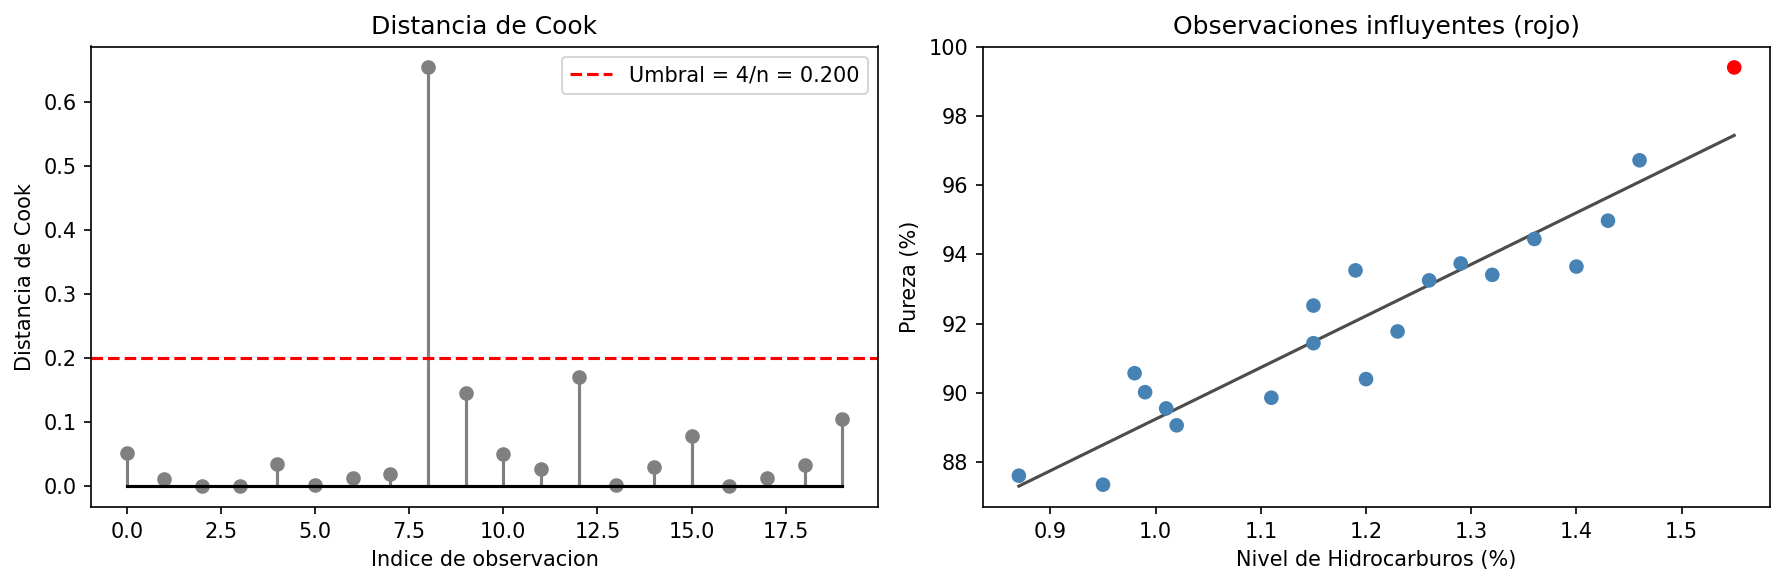

Observaciones con D_i > 0.200: indices [8]
     hc  pureza
8  1.55   99.42


In [12]:
influence = modelo.get_influence()
cook_d, _ = influence.cooks_distance
umbral = 4 / n_o  # regla practica

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# Panel izquierdo: Cook's distance
axes[0].stem(range(n_o), cook_d, markerfmt='o', linefmt='grey', basefmt='k-')
axes[0].axhline(umbral, color='red', linestyle='--', label=f'Umbral = 4/n = {umbral:.3f}')
axes[0].set_xlabel('Indice de observacion')
axes[0].set_ylabel('Distancia de Cook')
axes[0].set_title('Distancia de Cook')
axes[0].legend()

# Panel derecho: recta con puntos influyentes marcados
colores = ['red' if d > umbral else 'steelblue' for d in cook_d]
axes[1].scatter(x, y, c=colores, zorder=3)
axes[1].plot(x_range, y_hat_range, color='black', alpha=0.7)
axes[1].set_xlabel('Nivel de Hidrocarburos (%)')
axes[1].set_ylabel('Pureza (%)')
axes[1].set_title('Observaciones influyentes (rojo)')

plt.tight_layout()
plt.show()

influyentes = np.where(cook_d > umbral)[0]
print(f'Observaciones con D_i > {umbral:.3f}: indices {influyentes}')
if len(influyentes):
    print(df.iloc[influyentes].to_string())

### 5.2 Análisis de Residuos

Los residuos $\hat{\varepsilon}_i = y_i - \hat{y}_i$ son la herramienta principal para verificar los supuestos del modelo.

**Supuestos a verificar:**

| Supuesto | Gráfico | Test formal |
|----------|---------|-------------|
| Normalidad | Q-Q plot, histograma | Shapiro-Wilk |
| Homocedasticidad | Residuos vs $\hat{y}$ | Breusch-Pagan |
| Linealidad | Residuos vs $\hat{y}$ | — |
| Independencia | Orden temporal | Durbin-Watson |

**Interpretación visual:**
- *Q-Q plot*: los puntos deben seguir la línea diagonal roja.
- *Residuos vs $\hat{y}$*: los puntos deben dispersarse aleatoriamente alrededor del cero, sin patrones ni "embudos".

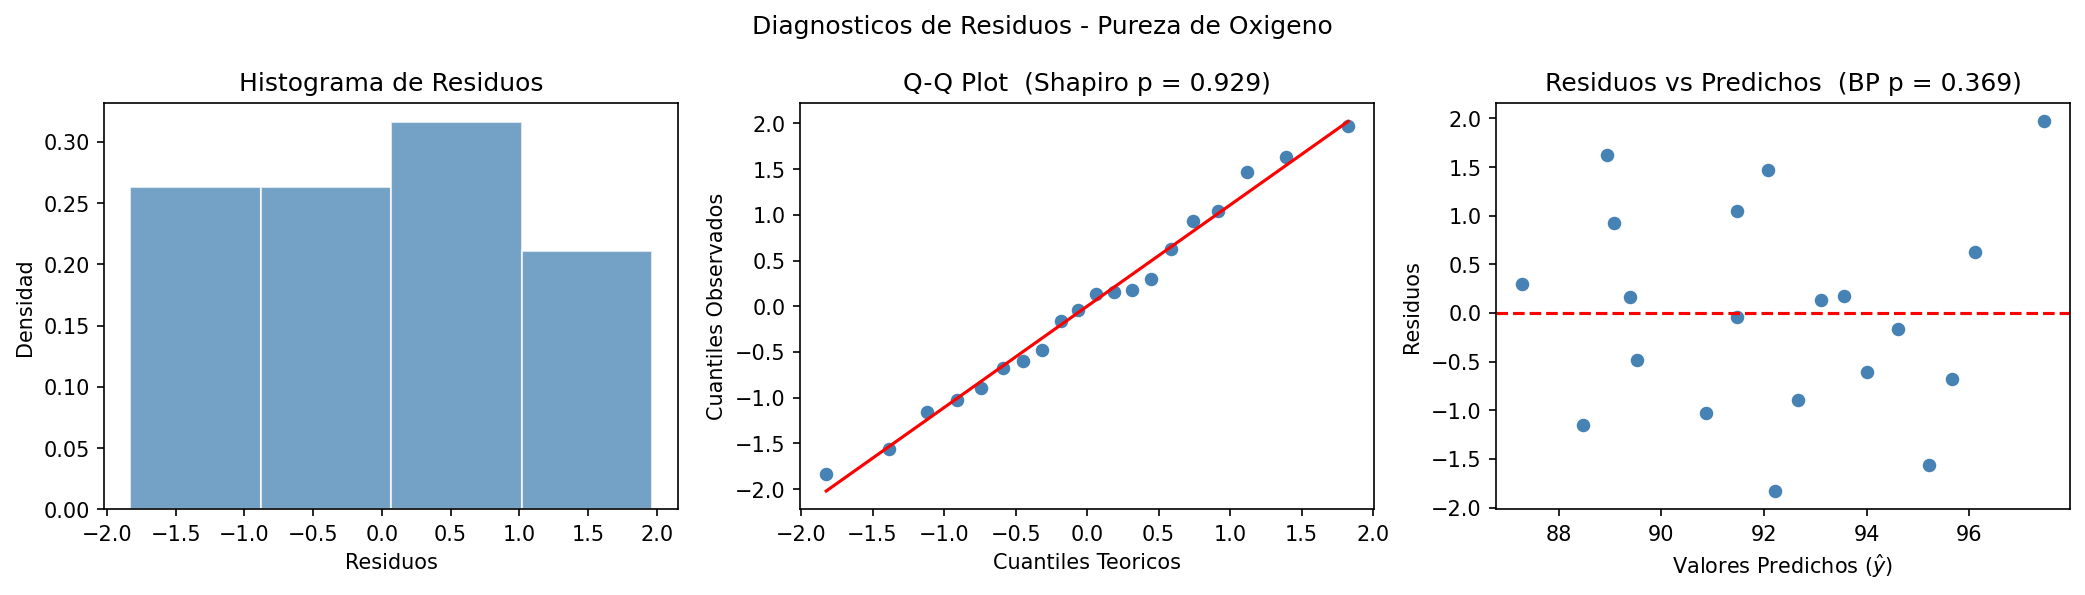

Shapiro-Wilk: W = 0.9796,  p = 0.9293
Breusch-Pagan:                          p = 0.3691

Normalidad OK?       True  (Shapiro p > 0.05)
Homocedasticidad OK? True  (Breusch-Pagan p > 0.05)


In [13]:
# Tests formales
shapiro_stat, shapiro_p = stats.shapiro(residuos)
_, bp_p, _, _ = het_breuschpagan(residuos, modelo.model.exog)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=150)

# Panel 1: histograma de residuos
axes[0].hist(residuos, bins=int(np.sqrt(n_o)), density=True,
             alpha=0.75, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Histograma de Residuos')

# Panel 2: Q-Q plot
(osm, osr), (slope, intercept, _) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, color='steelblue', s=30)
axes[1].plot(osm, slope * osm + intercept, color='red')
axes[1].set_xlabel('Cuantiles Teoricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].set_title(f'Q-Q Plot  (Shapiro p = {shapiro_p:.3f})')

# Panel 3: residuos vs valores predichos
axes[2].scatter(y_hat, residuos, color='steelblue', s=30)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores Predichos ($\\hat{y}$)')
axes[2].set_ylabel('Residuos')
axes[2].set_title(f'Residuos vs Predichos  (BP p = {bp_p:.3f})')

plt.suptitle('Diagnosticos de Residuos - Pureza de Oxigeno', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Shapiro-Wilk: W = {shapiro_stat:.4f},  p = {shapiro_p:.4f}')
print(f'Breusch-Pagan:                          p = {bp_p:.4f}')
print()
alpha_test = 0.05
norm_ok = shapiro_p > alpha_test
homo_ok = bp_p > alpha_test
print(f'Normalidad OK?       {norm_ok}  (Shapiro p > 0.05)')
print(f'Homocedasticidad OK? {homo_ok}  (Breusch-Pagan p > 0.05)')

---
## 6. Violaciones de Supuestos: Caso VideoJuegos

Cuando los supuestos se violan, los resultados del modelo pueden ser engañosos. Exploraremos este problema con el dataset de videojuegos, donde las ventas globales tienen una distribución muy sesgada (pocos juegos venden enormemente).

### 6.1 Diagnóstico de violaciones

/Users/gabbi/miniconda3/envs/SaaLab/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7191.
  res = hypotest_fun_out(*samples, **kwds)


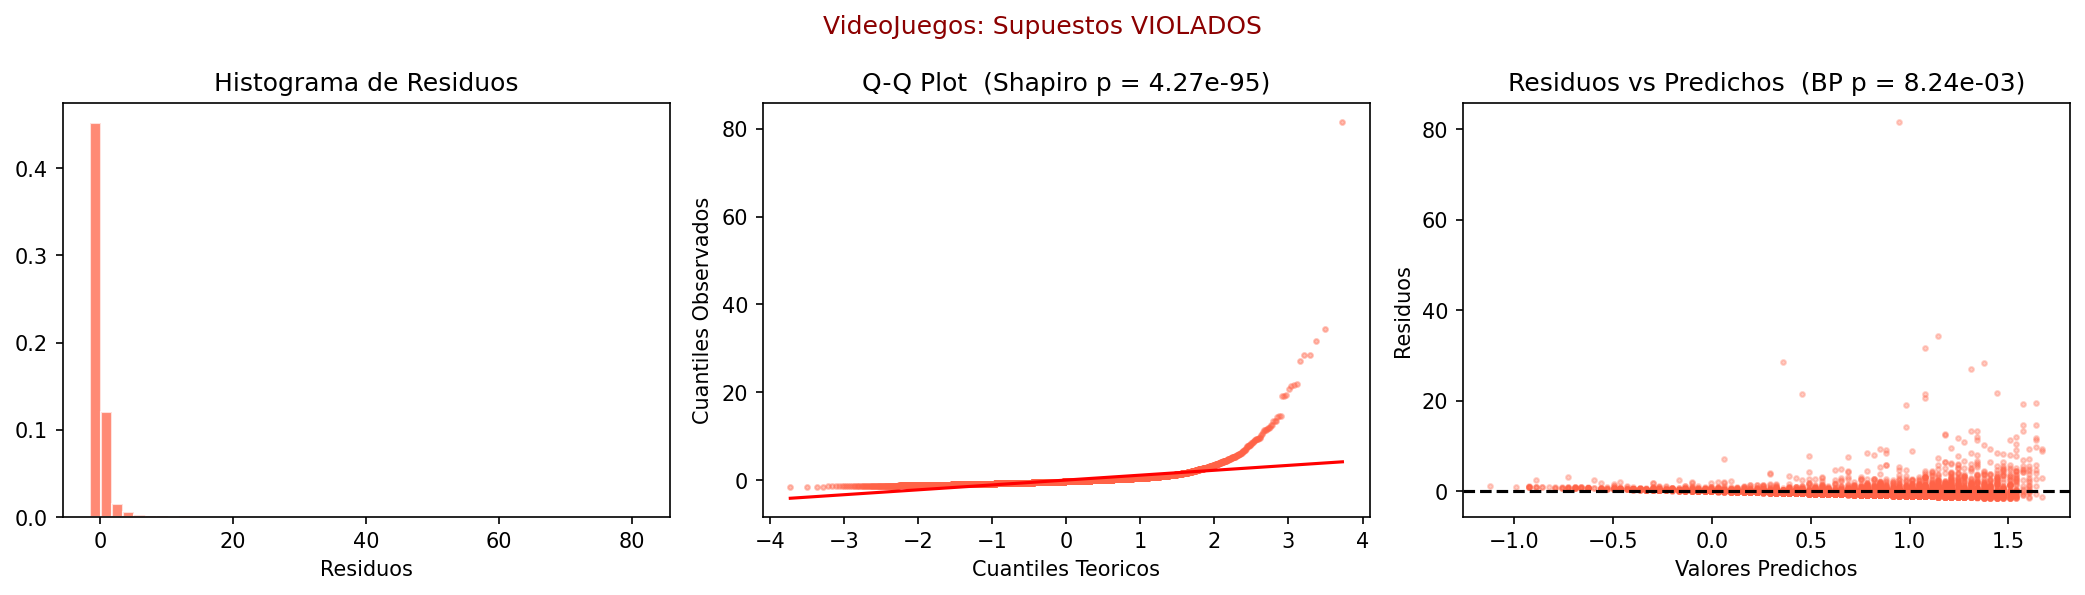

R^2 original             = 0.0561
Shapiro-Wilk p-value     = 4.27e-95  (<<0.05: no normal)
Breusch-Pagan p-value    = 8.24e-03  (<<0.05: heteroscedasticidad)


In [14]:
x_vg = vg_num['Critic_Score']
y_vg = vg_num['Global_Sales']
n_vg = len(x_vg)

# Ajuste del modelo
X_vg = sm.add_constant(x_vg)
modelo_vg = sm.OLS(y_vg, X_vg).fit()
res_vg = modelo_vg.resid
yhat_vg = modelo_vg.fittedvalues

# Tests de supuestos
sw_p_vg = stats.shapiro(res_vg)[1]
_, bp_p_vg, _, _ = het_breuschpagan(res_vg, modelo_vg.model.exog)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=150)

axes[0].hist(res_vg, bins=50, density=True, alpha=0.75,
             color='tomato', edgecolor='white')
axes[0].set_title('Histograma de Residuos')
axes[0].set_xlabel('Residuos')

(osm_vg, osr_vg), (sl_vg, ic_vg, _) = stats.probplot(res_vg, dist='norm')
axes[1].scatter(osm_vg, osr_vg, color='tomato', s=5, alpha=0.4)
axes[1].plot(osm_vg, sl_vg * osm_vg + ic_vg, color='red')
axes[1].set_title(f'Q-Q Plot  (Shapiro p = {sw_p_vg:.2e})')
axes[1].set_xlabel('Cuantiles Teoricos')
axes[1].set_ylabel('Cuantiles Observados')

axes[2].scatter(yhat_vg, res_vg, s=5, alpha=0.3, color='tomato')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title(f'Residuos vs Predichos  (BP p = {bp_p_vg:.2e})')
axes[2].set_xlabel('Valores Predichos')
axes[2].set_ylabel('Residuos')

plt.suptitle('VideoJuegos: Supuestos VIOLADOS', color='darkred', fontsize=12)
plt.tight_layout()
plt.show()

print(f'R^2 original             = {modelo_vg.rsquared:.4f}')
print(f'Shapiro-Wilk p-value     = {sw_p_vg:.2e}  (<<0.05: no normal)')
print(f'Breusch-Pagan p-value    = {bp_p_vg:.2e}  (<<0.05: heteroscedasticidad)')

### 6.2 Transformación Logarítmica

Cuando la variable de respuesta está fuertemente sesgada (como datos económicos o de conteo), la **transformación logarítmica** suele estabilizar la varianza y aproximar la normalidad:

$$y^* = \log(1 + y)$$

Se usa $\log(1 + y)$ en lugar de $\log(y)$ para manejar el caso $y = 0$ sin error.

**Interpretación del modelo log-transformado:** el modelo predice $\log(1 + \text{ventas})$. Para obtener la predicción en escala original:
$$\hat{y} = e^{\hat{y}^*} - 1$$

> **Comparación de $R^2$**: al transformar $y$, el $R^2$ no es directamente comparable con el del modelo original (miden varianza en escalas distintas). Lo importante es que los supuestos se cumplan *en la escala modelada*.

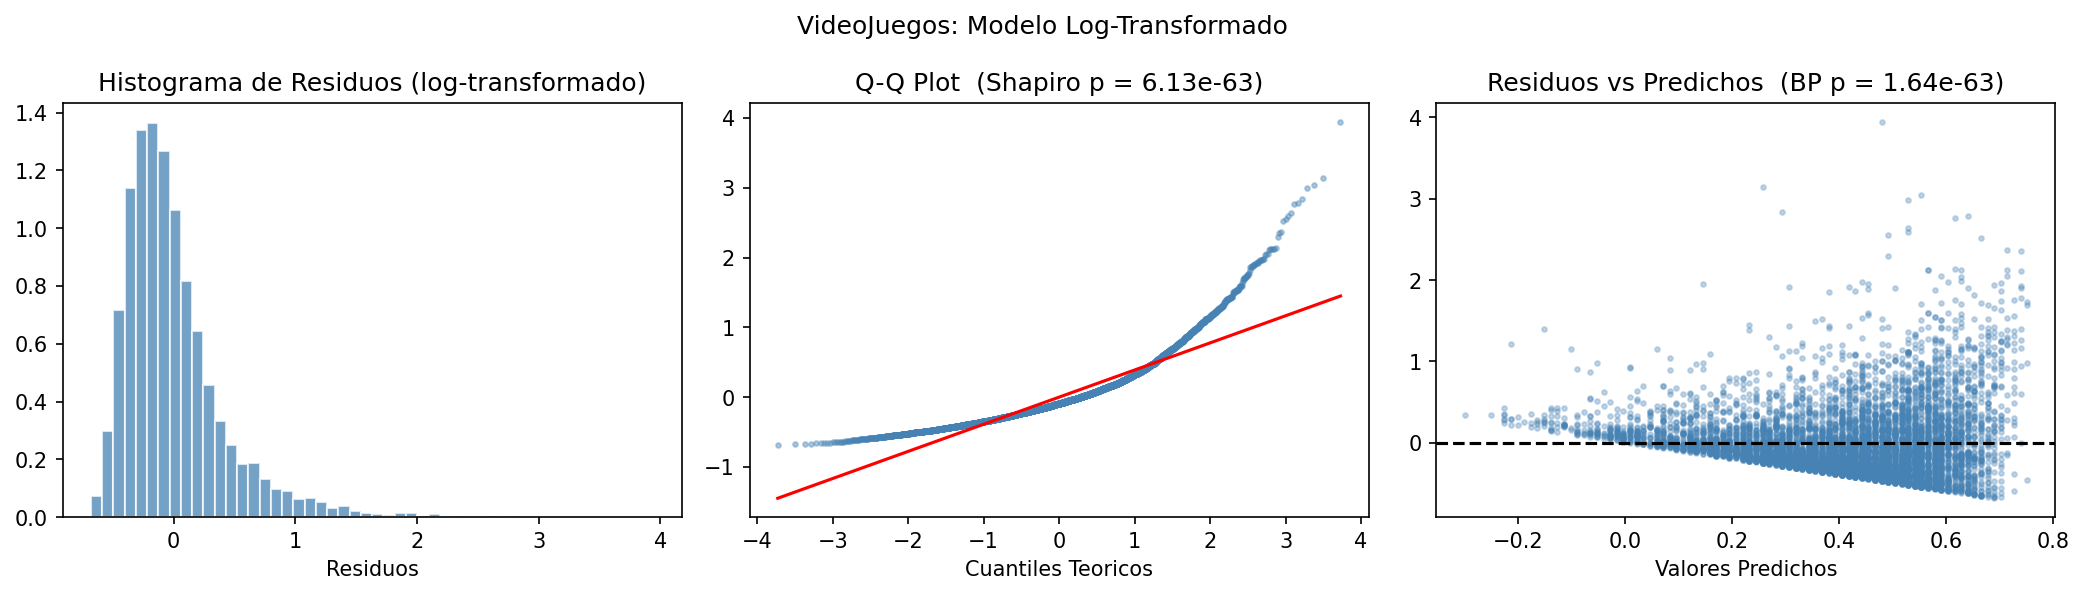

Comparacion de modelos:
  R^2 original      = 0.0561
  R^2 log-transform = 0.1431  (escala diferente)
  Shapiro p (orig)  = 4.27e-95
  Shapiro p (log)   = 6.13e-63
  BP p (orig)       = 8.24e-03
  BP p (log)        = 1.64e-63


In [15]:
# Transformacion logaritmica de la variable de respuesta
y_log = np.log1p(y_vg)

modelo_log = sm.OLS(y_log, X_vg).fit()
res_log = modelo_log.resid
yhat_log = modelo_log.fittedvalues

sw_p_log = stats.shapiro(res_log)[1]
_, bp_p_log, _, _ = het_breuschpagan(res_log, modelo_log.model.exog)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=150)

axes[0].hist(res_log, bins=50, density=True, alpha=0.75,
             color='steelblue', edgecolor='white')
axes[0].set_title('Histograma de Residuos (log-transformado)')
axes[0].set_xlabel('Residuos')

(osm_l, osr_l), (sl_l, ic_l, _) = stats.probplot(res_log, dist='norm')
axes[1].scatter(osm_l, osr_l, color='steelblue', s=5, alpha=0.4)
axes[1].plot(osm_l, sl_l * osm_l + ic_l, color='red')
axes[1].set_title(f'Q-Q Plot  (Shapiro p = {sw_p_log:.2e})')
axes[1].set_xlabel('Cuantiles Teoricos')

axes[2].scatter(yhat_log, res_log, s=5, alpha=0.3, color='steelblue')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title(f'Residuos vs Predichos  (BP p = {bp_p_log:.2e})')
axes[2].set_xlabel('Valores Predichos')

plt.suptitle('VideoJuegos: Modelo Log-Transformado', fontsize=12)
plt.tight_layout()
plt.show()

print('Comparacion de modelos:')
print(f'  R^2 original      = {modelo_vg.rsquared:.4f}')
print(f'  R^2 log-transform = {modelo_log.rsquared:.4f}  (escala diferente)')
print(f'  Shapiro p (orig)  = {sw_p_vg:.2e}')
print(f'  Shapiro p (log)   = {sw_p_log:.2e}')
print(f'  BP p (orig)       = {bp_p_vg:.2e}')
print(f'  BP p (log)        = {bp_p_log:.2e}')

---
## 7. Regresión Lineal Múltiple

La **regresión lineal múltiple** extiende el modelo a $p$ variables explicativas:

$$Y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \varepsilon$$

En forma matricial:
$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

El estimador OLS es: $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$

### 7.1 $R^2$ Ajustado

Al agregar más predictores, el $R^2$ siempre aumenta (aunque sean irrelevantes). El **$R^2$ ajustado** penaliza por el número de predictores $p$:

$$R^2_{adj} = 1 - \frac{SS_E / (n - p - 1)}{SS_T / (n - 1)}$$

Para comparar modelos con diferente número de predictores, usar $R^2_{adj}$ en lugar de $R^2$.

### 7.2 Multicolinealidad y VIF

Cuando los predictores están altamente correlacionados entre sí (**multicolinealidad**), los coeficientes se vuelven inestables. El **Factor de Inflación de la Varianza (VIF)** detecta este problema:

$$VIF_j = \frac{1}{1 - R^2_j}$$

donde $R^2_j$ es el $R^2$ de la regresión de $x_j$ sobre los demás predictores. Como regla práctica: $VIF > 10$ indica multicolinealidad problemática.

In [16]:
# Regresion multiple: predecir Global_Sales con Critic_Score + User_Score
vg_multi = vg_num[['Global_Sales', 'Critic_Score', 'User_Score']].dropna()
y_multi = vg_multi['Global_Sales']
X_multi = sm.add_constant(vg_multi[['Critic_Score', 'User_Score']])

modelo_multi = sm.OLS(y_multi, X_multi).fit()
print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     228.7
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           5.09e-97
Time:                        00:54:14   Log-Likelihood:                -14700.
No. Observations:                7191   AIC:                         2.941e+04
Df Residuals:                    7188   BIC:                         2.943e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.2560      0.126     -9.957   

In [17]:
# Comparacion SLR vs regresion multiple
modelo_slr_cr = sm.OLS(y_multi, sm.add_constant(vg_multi['Critic_Score'])).fit()
modelo_slr_us = sm.OLS(y_multi, sm.add_constant(vg_multi['User_Score'])).fit()

print('Comparacion de modelos:')
print(f'  SLR (Critic_Score):       R^2 = {modelo_slr_cr.rsquared:.4f},  R^2_adj = {modelo_slr_cr.rsquared_adj:.4f}')
print(f'  SLR (User_Score):         R^2 = {modelo_slr_us.rsquared:.4f},  R^2_adj = {modelo_slr_us.rsquared_adj:.4f}')
print(f'  Multiple (CR + US):       R^2 = {modelo_multi.rsquared:.4f},  R^2_adj = {modelo_multi.rsquared_adj:.4f}')
print()

# Calculo del VIF para los predictores
vif_data = pd.DataFrame({
    'Variable': X_multi.columns,
    'VIF': [variance_inflation_factor(X_multi.values, i)
            for i in range(X_multi.shape[1])]
})
print('Factor de Inflacion de la Varianza (VIF):')
print(vif_data.round(3))
print()
print('Regla practica: VIF > 10 indica multicolinealidad problematica.')

Comparacion de modelos:
  SLR (Critic_Score):       R^2 = 0.0561,  R^2_adj = 0.0559
  SLR (User_Score):         R^2 = 0.0078,  R^2_adj = 0.0076
  Multiple (CR + US):       R^2 = 0.0598,  R^2_adj = 0.0596

Factor de Inflacion de la Varianza (VIF):
       Variable     VIF
0         const  32.758
1  Critic_Score   1.514
2    User_Score   1.514

Regla practica: VIF > 10 indica multicolinealidad problematica.


In [18]:
# Interpretacion de coeficientes del modelo multiple
coef_multi = pd.DataFrame({
    'coef':    modelo_multi.params,
    'se':      modelo_multi.bse,
    't':       modelo_multi.tvalues,
    'p-value': modelo_multi.pvalues,
    'CI_low':  modelo_multi.conf_int()[0],
    'CI_high': modelo_multi.conf_int()[1]
})
print('Coeficientes del modelo multiple:')
print(coef_multi.round(4))
print()
print('Interpretacion:')
b1 = modelo_multi.params['Critic_Score']
b2 = modelo_multi.params['User_Score']
print(f'  Manteniendo User_Score constante, un punto mas en Critic_Score')
print(f'  se asocia con {b1:.4f} millones de unidades adicionales de Global_Sales.')
print(f'  Manteniendo Critic_Score constante, un punto mas en User_Score')
print(f'  se asocia con {b2:.4f} millones de unidades adicionales de Global_Sales.')

Coeficientes del modelo multiple:
                coef      se        t  p-value  CI_low  CI_high
const        -1.2560  0.1261  -9.9568      0.0 -1.5033  -1.0087
Critic_Score  0.0390  0.0020  19.9480      0.0  0.0351   0.0428
User_Score   -0.1006  0.0188  -5.3555      0.0 -0.1374  -0.0638

Interpretacion:
  Manteniendo User_Score constante, un punto mas en Critic_Score
  se asocia con 0.0390 millones de unidades adicionales de Global_Sales.
  Manteniendo Critic_Score constante, un punto mas en User_Score
  se asocia con -0.1006 millones de unidades adicionales de Global_Sales.


---
## 8. Síntesis

### Flujo de trabajo recomendado

1. **Exploración**: matriz de correlación, scatter plots.
2. **Ajuste**: OLS con `statsmodels.OLS` + `sm.add_constant`.
3. **Bondad de ajuste**: $R^2$, $R^2_{adj}$, RSE.
4. **Inferencia**: t-tests para $\beta_j$, F-test global, intervalos de confianza.
5. **Diagnósticos**: Cook's distance, Q-Q plot, Shapiro-Wilk, Breusch-Pagan, residuos vs $\hat{y}$.
6. **Remediación**: transformación logarítmica, modelos robustos.
7. **Modelos múltiples**: comparar con $R^2_{adj}$, verificar VIF.

### Tabla resumen

| Concepto | Qué mide | Python |
|---|---|---|
| $R_{XY}$ (Pearson) | Asociación lineal | `stats.pearsonr(x, y)` |
| $\rho_s$ (Spearman) | Asociación monotónica | `stats.spearmanr(x, y)` |
| $\hat{\beta}_0, \hat{\beta}_1$ | Intercepto y pendiente OLS | `sm.OLS(y, sm.add_constant(x)).fit()` |
| $R^2$ | Fracción de varianza explicada | `model.rsquared` |
| $R^2_{adj}$ | $R^2$ penalizado por # predictores | `model.rsquared_adj` |
| RSE / $\hat{\sigma}$ | Error en unidades de $y$ | `np.sqrt(model.mse_resid)` |
| $T_0$ (pendiente) | Test $H_0: \beta_1 = 0$ | `model.tvalues`, `model.pvalues` |
| IC coeficientes | Incertidumbre de $\hat{\beta}$ | `model.conf_int()` |
| $F_0$ (ANOVA) | Significancia global | `model.fvalue`, `model.f_pvalue` |
| Distancia de Cook | Influencia de cada punto | `model.get_influence().cooks_distance` |
| Shapiro-Wilk | Normalidad de residuos | `stats.shapiro(resid)` |
| Breusch-Pagan | Homocedasticidad | `het_breuschpagan(resid, exog)` |
| VIF | Multicolinealidad | `variance_inflation_factor(X, j)` |

### Referencia

- Montgomery, D.C. & Runger, G.C. (2019). *Applied Statistics and Probability for Engineers*, 7th ed. Wiley. Capítulos 11–12.